# Energy Demand Time Series Analysis

## 1. Import Data

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from coloured_line_points import colored_line
import numpy as np
import re
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
#monthly electricity  production series
#https://explore.openelectricity.org.au/energy/nem/?range=all&interval=1M&view=discrete-time&group=Detailed

data_folder = os.path.join(os.getcwd(), r'raw data - open electricity data')
file_name = '19981201 Open Electricity.csv'
path = os.path.join(data_folder,file_name)

elec_data = pd.read_csv(path)


# standardise the column names
elec_data.columns = elec_data.columns.str.lower().str.replace(r'[^\w\s]', '', regex=True).str.replace(' ', '_')
elec_data.columns = elec_data.columns.str.replace('___', '_').str.replace('__', '_')

#list(elec_data.columns)

#average daily over 28 days electricity generation
data_folder = os.path.join(os.getcwd(), r'raw data - open electricity data')
file_name = '20260106 Open Electricity - hourly.csv'
path = os.path.join(data_folder,file_name)

elec_data_hourly = pd.read_csv(path)

In [3]:
#csv Daily Electricity Price and Demand Data
#https://www.kaggle.com/datasets/aramacus/electricity-demand-in-victoria-australia/data

#get data folder path
data_folder = os.path.join(os.getcwd(), r'raw data - vic electricity')
file_name = 'electricity_demand_data_vic.csv'

# #import data
# path = os.path.join(data_folder,file_name)
# vic_elec = pd.read_csv( path)

# #move to parquet
# file_name = 'electricity_demand_data_vic.parquet'
# path = os.path.join(data_folder,file_name)
# vic_elec.to_parquet(path)

# del vic_elec

#import parquet df
file_name = 'electricity_demand_data_vic.parquet'
path = os.path.join(data_folder,file_name)
vic_elec = pd.read_parquet(path)

#vic_elec.describe()


Fields
-    date : datetime, the date of the recording
-    demand : float, a total daily electricity demand in MWh
-    RRP : float, a recommended retail price in AUD$ / MWh
-    demand_pos_RRP : float, a total daily demand at positive RRP in MWh
-    RRP_positive : float, an averaged positive RRP, weighted by the corresponding intraday demand in AUD$ / MWh
-    demand_neg_RRP : float, an total daily demand at negative RRP in MWh
-    RRP_negative : float, an average negative RRP, weighted by the corresponding intraday demand in AUD$ / MWh
-    frac_at_neg_RRP : float, a fraction of the day when the demand was traded at negative RRP
-    min_temperature : float, minimum temperature during the day in Celsius
-    max_temperature : float, maximum temperature during the day in Celsius
-    solar_exposure : float, total daily sunlight energy in MJ/m^2
-    rainfall : float, daily rainfall in mm
-    school_day : boolean, if students were at school on that day
-    holiday : boolean, if the day was a state or national holiday


## 2. Analysis

In [4]:
#reduce number of columns
cols = ['date',
            'battery_charging_gwh',
            'pumps_gwh',
            'coal_brown_gwh',
            'coal_black_gwh',
            'bioenergy_biomass_gwh',
            'distillate_gwh',
            'gas_steam_gwh',
            'gas_ccgt_gwh',
            'gas_ocgt_gwh',
            'gas_reciprocating_gwh',
            'gas_waste_coal_mine_gwh',
            'battery_discharging_gwh',
            'hydro_gwh',
            'wind_gwh',
            'solar_utility_gwh',
            'solar_rooftop_gwh',
            'wind_curtailment_gwh',
            'solar_utility_curtailment_gwh']

elec_data = elec_data[cols]

#create grouped variables
elec_data['total_coal'] = elec_data[['coal_black_gwh','coal_brown_gwh']].sum(axis=1)
elec_data['total_gas'] = elec_data[['gas_steam_gwh','gas_ccgt_gwh','gas_ocgt_gwh', 'gas_reciprocating_gwh', 'gas_waste_coal_mine_gwh']].sum(axis=1)
elec_data['total_solar'] = elec_data[['solar_utility_gwh','solar_rooftop_gwh']].sum(axis=1)
elec_data['total_wind'] = elec_data[['wind_gwh']].sum(axis=1)
elec_data['total_hydro'] = elec_data[['hydro_gwh']].sum(axis=1)
elec_data['total_other_net'] = elec_data[['battery_charging_gwh','pumps_gwh','bioenergy_biomass_gwh','distillate_gwh','battery_discharging_gwh']].sum(axis=1) #,'wind_curtailment_gwh','solar_utility_curtailment_gwh'

elec_data['total_gwh_net'] = elec_data[['total_coal','total_gas','total_solar','total_wind', 'total_hydro','total_other_net']].sum(axis=1)

#datetime
elec_data['date'] = pd.to_datetime(elec_data['date'], dayfirst=True)


In [5]:
#reduce number of columns
cols = ['date','total_gwh_net','total_coal','total_gas','total_solar','total_wind', 'total_hydro','total_other_net']

elec_data = elec_data[cols]

elec_data = elec_data.set_index('date')

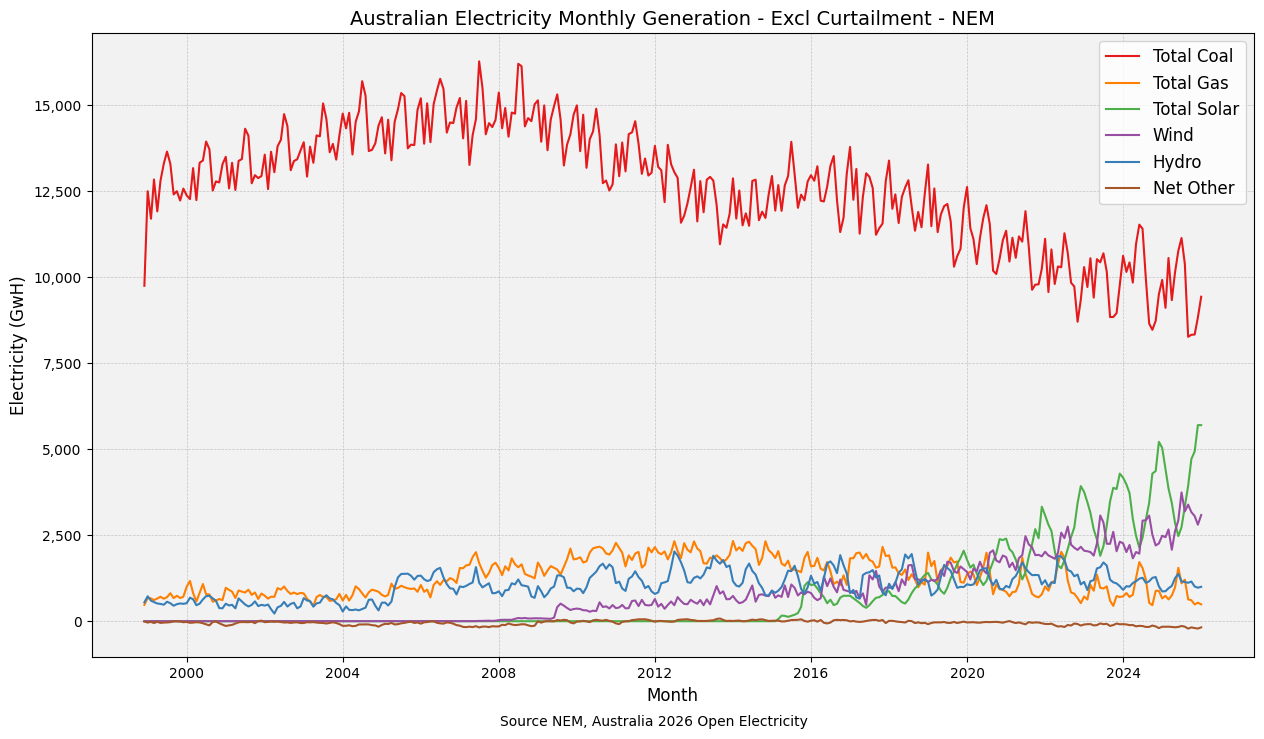

In [6]:
#plot simple total series

fig, axs = plt.subplots(1, figsize=(15, 8))

font_size = 12

colors = plt.get_cmap('Set1').colors
series = ['Total Coal','Total Gas','Total Solar','Wind', 'Hydro','Net Other']
#plot
axs.plot(elec_data[['total_coal']],label=series[0], color=colors[0])
axs.plot(elec_data[['total_gas']],label=series[1], color=colors[4])
axs.plot(elec_data[['total_solar']],label=series[2], color=colors[2])
axs.plot(elec_data[['total_wind']],label=series[3], color=colors[3])
axs.plot(elec_data[['total_hydro']],label=series[4], color=colors[1])
axs.plot(elec_data[['total_other_net']],label=series[5], color=colors[6])

axs.set_xlabel('Month', fontsize=font_size)
axs.set_ylabel('Electricity (GwH)', fontsize=font_size)
axs.set_title('Australian Electricity Monthly Generation - Excl Curtailment - NEM', fontsize=font_size+2)

#add more specific elements
axs.legend(fontsize=font_size)
axs.xaxis_date() 
axs.xaxis.set_major_locator(mdates.AutoDateLocator())
axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axs.set_facecolor('#f2f2f2')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
#add text box
caveat_text = '''Source NEM, Australia 2026 Open Electricity'''
# Add text to the figure
# Adjust bottom margin to make space for text
plt.subplots_adjust(bottom=0.1)
fig.text(0.5, 0.01, caveat_text, ha='center', va='bottom', fontsize=font_size-2)

plt.show()

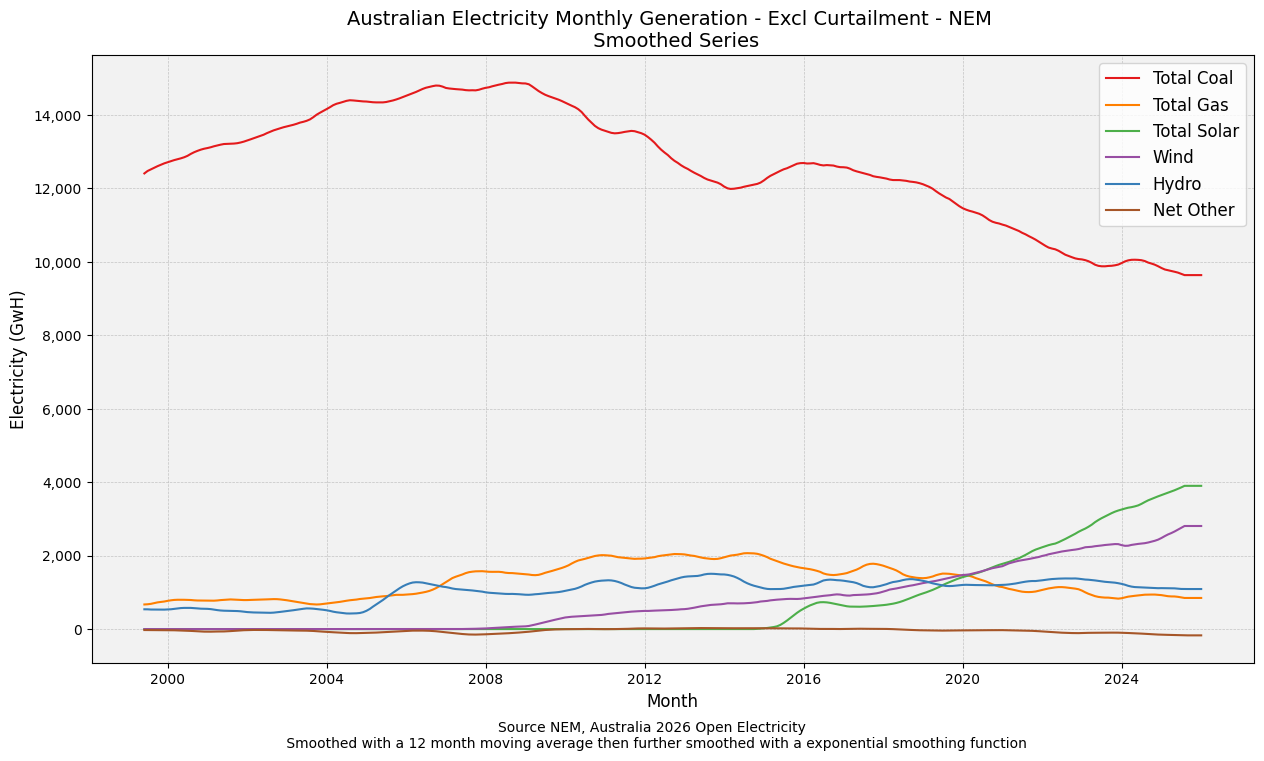

In [7]:
#plot smoothed total series

fig, axs = plt.subplots(1, figsize=(15, 8))

font_size = 12

colors = plt.get_cmap('Set1').colors
series =  ['Total Coal','Total Gas','Total Solar','Wind', 'Hydro','Net Other']

#create function for smoothing
def smoothing_ama(raw_series, window = 12, super_smooth= False, span = 6):
    ''' Arithmetic moving average, demands a pandas column and the window width. Uses Centering Window.
    If super_smooth is True, then also apply a exponential smoother.'''
    x = raw_series.rolling(window ,center=True).mean()
    if super_smooth == True:
        x = x.ewm(span=span, adjust=False).mean()
    return x


#plot
axs.plot(smoothing_ama(elec_data[['total_coal']], super_smooth= True),label=series[0], color=colors[0])
#axs.plot(elec_data[['total_coal']].ewm(span=12, adjust=False).mean(),label=series[0], color=colors[0])
axs.plot(smoothing_ama(elec_data[['total_gas']], super_smooth= True),label=series[1], color=colors[4])
axs.plot(smoothing_ama(elec_data[['total_solar']], super_smooth= True),label=series[2], color=colors[2])
axs.plot(smoothing_ama(elec_data[['total_wind']], super_smooth= True),label=series[3], color=colors[3])
axs.plot(smoothing_ama(elec_data[['total_hydro']], super_smooth= True),label=series[4], color=colors[1])
axs.plot(smoothing_ama(elec_data[['total_other_net']], super_smooth= True),label=series[5], color=colors[6])

axs.set_xlabel('Month', fontsize=font_size)
axs.set_ylabel('Electricity (GwH)', fontsize=font_size)
axs.set_title('Australian Electricity Monthly Generation - Excl Curtailment - NEM \n Smoothed Series', fontsize=font_size+2)

#add more specific elements
axs.legend(fontsize=font_size)
axs.xaxis_date() 
axs.xaxis.set_major_locator(mdates.AutoDateLocator())
axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axs.set_facecolor('#f2f2f2')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

#add text box
caveat_text = '''Source NEM, Australia 2026 Open Electricity \n Smoothed with a 12 month moving average then further smoothed with a exponential smoothing function'''
# Add text to the figure
# Adjust bottom margin to make space for text
plt.subplots_adjust(bottom=0.12)
fig.text(0.5, 0.01, caveat_text, ha='center', va='bottom', fontsize=font_size-2)

plt.show()

In [8]:
# Calculate proportions
elec_data_prop = elec_data[['total_coal','total_gas','total_solar','total_wind', 'total_hydro']]
elec_data_prop = elec_data_prop.div(elec_data_prop.sum(axis=1), axis=0)
#elec_data_prop.tail(30)


smoothed series:total_coal
smoothed series:total_gas
smoothed series:total_solar
smoothed series:total_wind
smoothed series:total_hydro


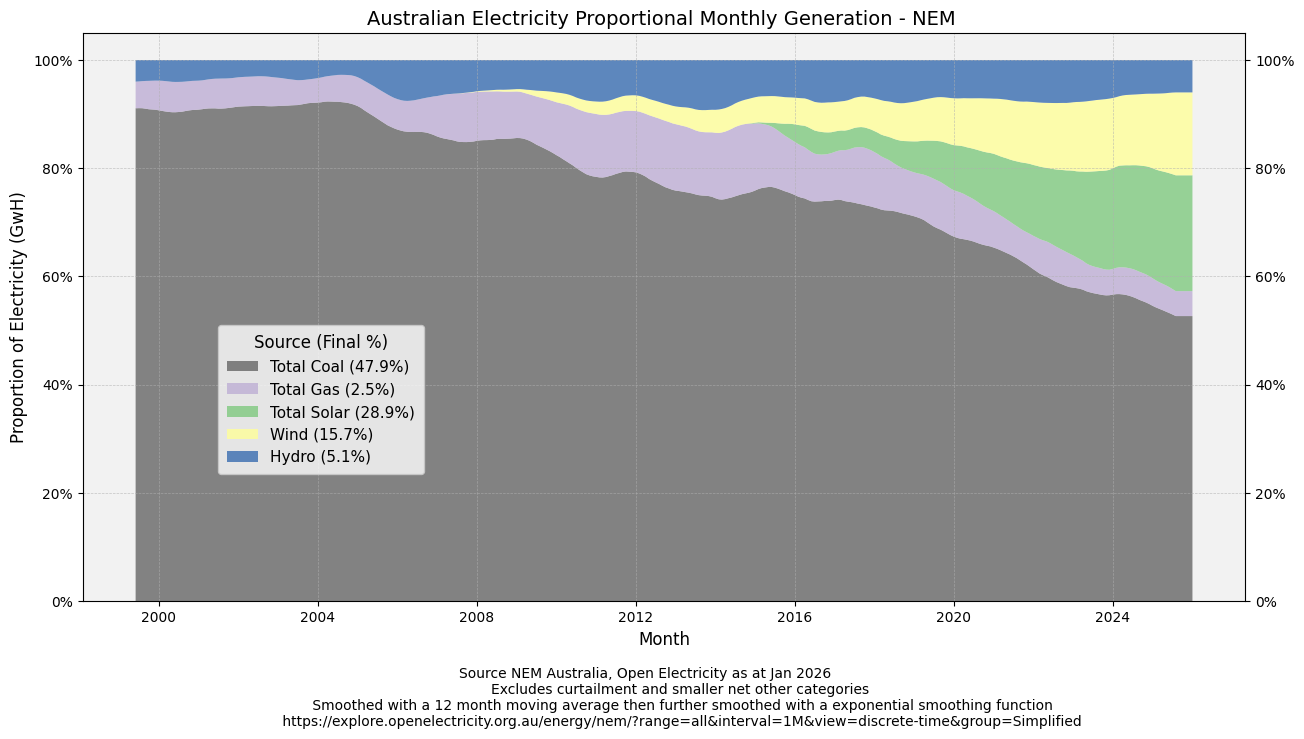

In [9]:

#plot smoothed total series prop

fig, axs = plt.subplots(1, figsize=(15, 8))

font_size = 12

colors = plt.get_cmap('Accent').colors
colors =  [colors[7], colors[1], colors[0], colors[3], colors[4]]


series =  ['Total Coal (' +str(np.round(elec_data_prop['total_coal'].iloc[-1]*100,1))+'%)',
           'Total Gas (' +str(np.round(elec_data_prop['total_gas'].iloc[-1]*100,1))+'%)',
           'Total Solar (' +str(np.round(elec_data_prop['total_solar'].iloc[-1]*100,1))+'%)',
           'Wind (' +str(np.round(elec_data_prop['total_wind'].iloc[-1]*100,1))+'%)',
           'Hydro (' +str(np.round(elec_data_prop['total_hydro'].iloc[-1]*100,1))+'%)']

#create function for smoothing
def smoothing_ama(raw_series, window = 12, super_smooth= False, span = 6):
    ''' Arithmetic moving average, demands a pandas column and the window width. Uses Centering Window.
    If super_smooth is True, then also apply a exponential smoother.'''
    x = raw_series.rolling(window ,center=True).mean()
    if super_smooth == True:
        x = x.ewm(span=span, adjust=False).mean()
    return x

for i in elec_data_prop.columns:
    elec_data_prop[i] = smoothing_ama(elec_data_prop[i], super_smooth=True, window = 12)
    print('smoothed series:'+ i)

#plot
axs.stackplot(elec_data_prop.index, elec_data_prop.T, labels=series , colors=colors, alpha =0.8)

axs.set_xlabel('Month', fontsize=font_size)
axs.set_ylabel('Proportion of Electricity (GwH)', fontsize=font_size)
axs.set_title('Australian Electricity Proportional Monthly Generation - NEM ', fontsize=font_size+2)

#add more specific elements
axs.legend(fontsize=font_size-1, bbox_to_anchor = (0.3,0.5), title = 'Source (Final %)',title_fontsize = font_size, borderpad = 0.6)
axs.xaxis_date() 
axs.xaxis.set_major_locator(mdates.AutoDateLocator())
axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0%}'))
axs.set_facecolor('#f2f2f2')
axs.yaxis.set_ticks_position('both')
axs.tick_params(labelleft=True, labelright=True)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


#add text box
caveat_text = '''Source NEM Australia, Open Electricity as at Jan 2026
                Excludes curtailment and smaller net other categories
                 Smoothed with a 12 month moving average then further smoothed with a exponential smoothing function
                 https://explore.openelectricity.org.au/energy/nem/?range=all&interval=1M&view=discrete-time&group=Simplified'''
# Add text to the figure
# Adjust bottom margin to make space for text
plt.subplots_adjust(bottom=0.17)
fig.text(0.5, 0.01, caveat_text, ha='center', va='bottom', fontsize=font_size-2)

plt.show()

In [17]:
##output to parquet

output_prop_data = elec_data_prop.dropna()

data_folder = os.path.join(os.getcwd(), 'Portfolio Output')
file_name = r'electricity_generation_by_type.parquet'

path = os.path.join(data_folder,file_name)
output_prop_data.to_parquet(path)

file_name = r'electricity_generation_by_type.xlsx'
path = os.path.join(data_folder,file_name)

output_prop_data.to_excel(path, index=False, sheet_name='Sheet1')

In [11]:
#hourly (half hour) daily average production electricity by source

elec_data_hourly['date'] = pd.to_datetime(elec_data_hourly['date'], dayfirst=True)

#time component
elec_data_hourly['time'] = elec_data_hourly['date'].dt.strftime('%H:%M')

# groub by and sort
categories = ['Coal -  GWh', 'Gas -  GWh', 'Battery (Discharging) -  GWh', 'Hydro -  GWh', 'Wind -  GWh', 'Solar -  GWh']
avg_prod = elec_data_hourly.groupby('time')[categories].mean().reset_index()

avg_prod['time_dt'] = pd.to_datetime(avg_prod['time'], format='%H:%M')
avg_prod = avg_prod.sort_values('time_dt').drop(columns=['time_dt'])


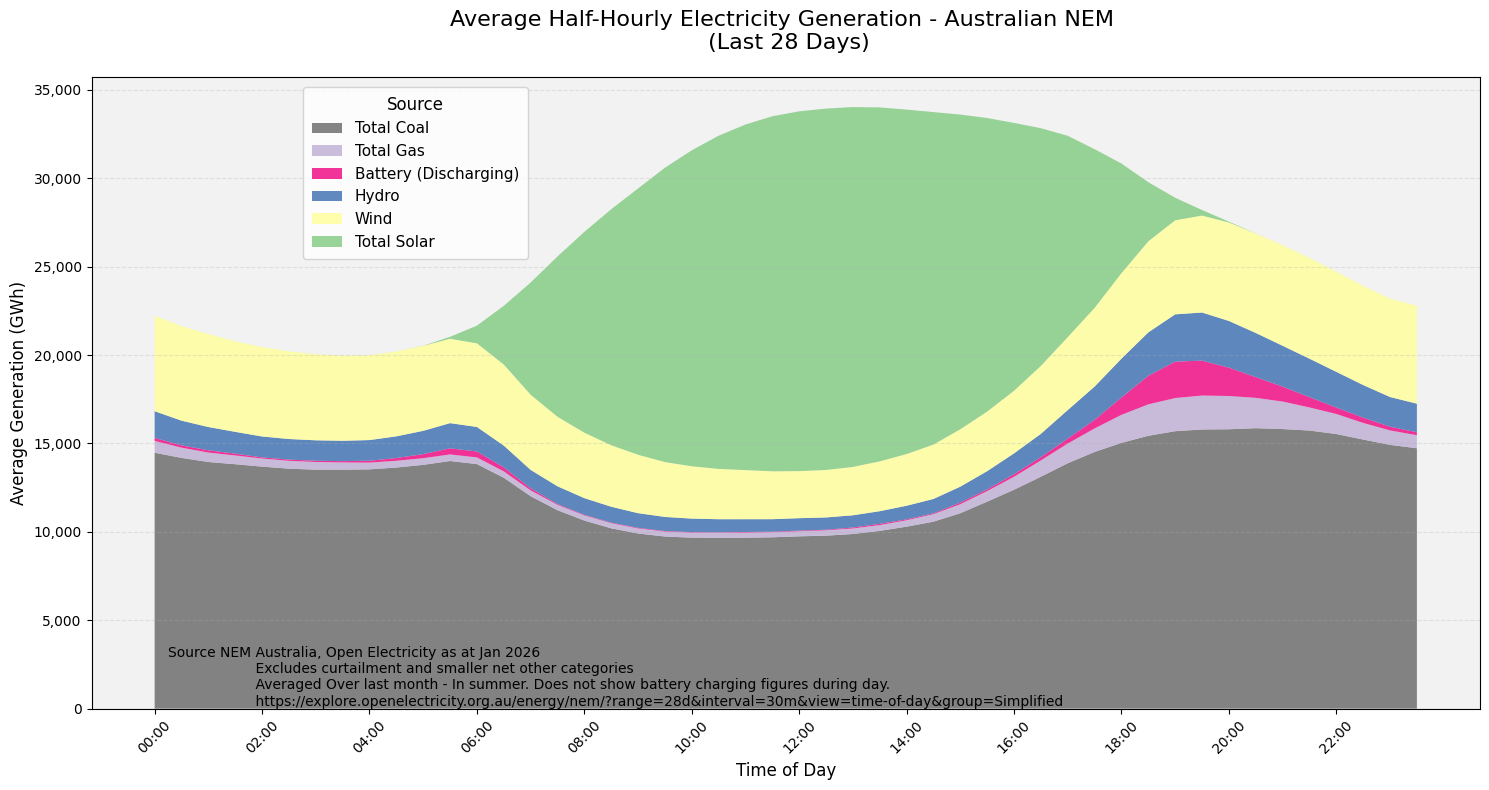

In [18]:
font_size = 12
# colours
colors = plt.get_cmap('Accent').colors
colors =  [colors[7], colors[1], colors[5] ,colors[4], colors[3], colors[0] ]
# Create the plot
plt.figure(figsize=(15, 8))

# Graph
plt.stackplot(avg_prod['time'], 
              [avg_prod[cat] for cat in categories], 
              labels=['Total Coal', 'Total Gas', 'Battery (Discharging)', 'Hydro', 'Wind', 'Total Solar'],
              colors=colors,
              alpha=0.8)


plt.title('Average Half-Hourly Electricity Generation - Australian NEM \n (Last 28 Days)', fontsize=font_size+4, pad=20)
plt.xlabel('Time of Day', fontsize=font_size)
plt.ylabel('Average Generation (GWh)', fontsize=font_size)
plt.legend(fontsize=font_size-1, bbox_to_anchor = (0.32,0.7), title = 'Source',title_fontsize = font_size, borderpad = 0.6, ncol=1)
tick_indices = range(0, len(avg_prod['time']), 4) 
plt.xticks(avg_prod['time'].iloc[tick_indices], rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().set_facecolor('#f2f2f2')
#add text box
caveat_text = '''Source NEM Australia, Open Electricity as at Jan 2026
                    Excludes curtailment and smaller net other categories
                    Averaged Over last month - In summer. Does not show battery charging figures during day. 
                    https://explore.openelectricity.org.au/energy/nem/?range=28d&interval=30m&view=time-of-day&group=Simplified'''
# Add text to the figure
# Adjust bottom margin to make space for text
plt.subplots_adjust(bottom=0.2)
plt.text( 0.5, 0.1, caveat_text, fontsize=font_size-2,  va='bottom')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [19]:
##output to parquet

output_28day_data = avg_prod

data_folder = os.path.join(os.getcwd(), 'Portfolio Output')
file_name = r'electricity_generation_by_hour.parquet'

path = os.path.join(data_folder,file_name)
output_28day_data.to_parquet(path)

file_name = r'electricity_generation_by_hour.xlsx'
path = os.path.join(data_folder,file_name)

output_28day_data.to_excel(path, index=False, sheet_name='Sheet1')

In [20]:
output_28day_data

,time,Coal - GWh,Gas - GWh,Battery (Discharging) - GWh,Hydro - GWh,Wind - GWh,Solar - GWh
0,00:00,14474.997241,666.611724,173.031034,1509.503448,5398.528621,0.995172
1,00:30,14182.796207,580.031034,129.925517,1396.936552,5348.970345,0.958276
2,01:00,13949.788621,534.362414,129.616207,1316.121379,5262.553103,0.943448
3,01:30,13825.406552,493.796207,101.849655,1234.635862,5117.325172,0.944138
4,02:00,13688.695862,458.327586,64.778276,1182.487241,5055.536897,0.941034
5,02:30,13574.490345,443.106897,69.855862,1163.516897,4954.941379,0.944828
6,03:00,13514.811034,437.013448,69.286552,1156.981034,4870.517931,0.935862
7,03:30,13515.344828,410.396552,73.582414,1151.358621,4814.882759,0.927931
8,04:00,13533.789310,381.808276,106.464828,1169.660000,4801.049310,0.936897
9,04:30,13637.376552,381.691379,156.091034,1226.263448,4799.089655,0.945172
